## 01: Import Libraries
We import the tools we need for this project:
- mne: to read the EDF sleep recording file
- numpy: to handle numbers and arrays
- matplotlib: to draw signal plots
- os: to build file paths on our computer

In [1]:
import mne
import numpy as np
import matplotlib.pyplot as plt
import os

print("All libraries imported")

All libraries imported


## 02: Load the EDF File
The EDF file contains all the sleep signals recorded overnight 
(ECG, EEG, Respiratory, and more) for one patient.
We load it using MNE and print basic information about it
like how many channels it has and how long the recording is.

In [2]:
DATA_PATH = r"C:\Users\EmaSk\Desktop\sleep-heart-health-study-psg-database-1.0.0\sleep-heart-health-study-psg-database-1.0.0"
EDF_FILE = os.path.join(DATA_PATH, "0000.edf")

raw = mne.io.read_raw_edf(EDF_FILE, preload=True, verbose=False)

print(f"File loaded")
print(f"Duration      : {raw.times[-1] / 3600:.2f} hours")
print(f"Sampling rate : {raw.info['sfreq']} Hz")
print(f"Total channels: {len(raw.ch_names)}")
print(f"\nAll channels:")
for i, ch in enumerate(raw.ch_names):
    print(f"  [{i}] {ch}")

C:\Users\EmaSk\AppData\Local\Temp\ipykernel_15760\297536103.py:4: RuntimeWarning: Invalid measurement date encountered in the header.
  raw = mne.io.read_raw_edf(EDF_FILE, preload=True, verbose=False)
C:\Users\EmaSk\AppData\Local\Temp\ipykernel_15760\297536103.py:4: RuntimeWarning: Number of records from the header does not match the file size (perhaps the recording was not stopped before exiting). Inferring from the file size.
  raw = mne.io.read_raw_edf(EDF_FILE, preload=True, verbose=False)


File loaded
Duration      : 9.00 hours
Sampling rate : 250.0 Hz
Total channels: 11

All channels:
  [0] SaO2
  [1] PR
  [2] EEG(sec)
  [3] ECG
  [4] EMG
  [5] EOG(L)
  [6] EOG(R)
  [7] EEG
  [8] AIRFLOW
  [9] THOR RES
  [10] ABDO RES


## 03: Extract the ECG Signal
From all 11 channels, we isolate only the ECG channel.
We extract the raw signal values and the time axis.
This gives us the heartbeat data we will analyze for apnea detection.

In [3]:
ecg_data, times = raw['ECG', :]
ecg_data = ecg_data[0]  # flatten from (1, N) to (N,)
sfreq = raw.info['sfreq']

print(f"ECG channel extracted")
print(f"Total samples : {len(ecg_data):,}")
print(f"Duration      : {len(ecg_data)/sfreq/3600:.2f} hours")
print(f"Sample rate   : {sfreq} Hz")
print(f"First 5 values: {ecg_data[:5]}")

ECG channel extracted
Total samples : 8,099,750
Duration      : 9.00 hours
Sample rate   : 250.0 Hz
First 5 values: [-0.00021569 -0.00023137 -0.00023137 -0.00022353 -0.00019216]


## 04: Load Apnea Annotations from .resp File
The .resp file tells us which 30-second windows of the night
had apnea events and which were normal breathing.
0 = Normal, 1 = Apnea event.
This is our label — what the model will learn to predict.

In [7]:
import wfdb

RECORD_PATH = os.path.join(DATA_PATH, "0000")

# Read annotations using wfdb
ann = wfdb.rdann(RECORD_PATH, 'resp')

print(f"Annotations loaded!")
print(f"Total annotations : {len(ann.sample)}")
print(f"Annotation types  : {set(ann.aux_note)}")
print(f"\nFirst 10 annotations:")
for i in range(min(10, len(ann.sample))):
    time_sec = ann.sample[i] / sfreq
    print(f"  [{i}] Time: {time_sec:.1f}s | Symbol: {ann.symbol[i]} | Note: {ann.aux_note[i]}")

Annotations loaded!
Total annotations : 217
Annotation types  : {'Hyp 0:10.3 1 97', 'Hyp 0:19.6 3 94', 'Hyp 0:12.1 2 94', 'Hyp 0:10.8 2 95', 'Hyp 0:15.7 3 94', 'Hyp 0:13.4 3 91', 'Hyp 0:25.2 6 90', 'Hyp 0:14.9 1 95', 'Hyp 0:17.0 1 95', 'Hyp 0:16.9 2 95', 'Hyp 0:10.6 2 95', 'Ob.A 0:16.7 3 95', 'Ob.A 0:18.8 10 88', 'Hyp 0:24.5 1 93', 'Hyp 0:15.7 4 94', 'Ob.A 0:15.1 2 95', 'Hyp 0:24.5 5 92', 'Hyp 0:29.4 3 94', 'Hyp 0:18.5 5 93', 'Hyp 0:12.8 1 93', 'Hyp 0:10.3 3 93', 'Hyp 0:13.1 2 95', 'Hyp 0:11.1 2 95', 'Hyp 0:11.6 2 94', 'Hyp 0:12.4 2 94', 'Hyp 0:30.9 5 90', 'Hyp 0:13.1 5 91', 'Hyp 0:21.4 7 90', 'Hyp 0:11.8 7 91', 'Hyp 0:20.0 7 89', 'Hyp 0:19.2 2 94', 'Hyp 0:18.3 6 92', 'Hyp 0:16.8 5 91', 'Hyp 0:12.6 2 94', 'Hyp 0:13.6 2 96', 'Hyp 0:14.2 3 93', 'Hyp 0:11.8 1 94', 'Hyp 0:14.6 2 92', 'Hyp 0:15.9 4 93', 'Ob.A 0:12.1 3 92', 'Hyp 0:12.6 1 95', 'Hyp 0:12.6 1 96', 'Hyp 0:18.2 1 95', 'Hyp 0:18.6 2 94', 'Hyp 0:12.6 3 94', 'Hyp 0:21.1 3 95', 'Hyp 0:16.5 5 93', 'Hyp 0:21.6 5 92', 'Hyp 0:14.7 1 97',

## 05: Convert Annotations to 30-Second Window Labels
The annotations tell us exactly WHEN each apnea event happened in seconds.
We divide the entire 9-hour recording into 30-second windows.
Any window that contains an apnea event gets label 1 (apnea).
All other windows get label 0 (normal).
This gives us one label per window — ready for machine learning.

In [10]:
# Total recording duration in seconds
total_seconds = len(ecg_data) / sfreq
window_size = 30  # seconds

# Create one label per 30s window, all starting as 0 (normal)
num_windows = int(total_seconds // window_size)
window_labels = np.zeros(num_windows, dtype=int)

# Mark windows that contain an apnea event as 1
for sample in ann.sample:
    event_sec = sample / sfreq
    window_idx = int(event_sec // window_size)
    if window_idx < num_windows:
        window_labels[window_idx] = 1

apnea_count = np.sum(window_labels == 1)
normal_count = np.sum(window_labels == 0)
total = len(window_labels)

print(f"Labels created")
print(f"Total 30s windows : {total}")
print(f"Normal windows    : {normal_count} ({100*normal_count/total:.1f}%)")
print(f"Apnea windows     : {apnea_count} ({100*apnea_count/total:.1f}%)")

Labels created
Total 30s windows : 1079
Normal windows    : 1074 (99.5%)
Apnea windows     : 5 (0.5%)


## 06: Plot the ECG Signal and Mark Apnea Events
Now we visualize the full night ECG signal.
Red shaded regions show exactly where apnea events occurred.
This helps us visually understand what the signal looks like
during normal breathing vs apnea episodes.

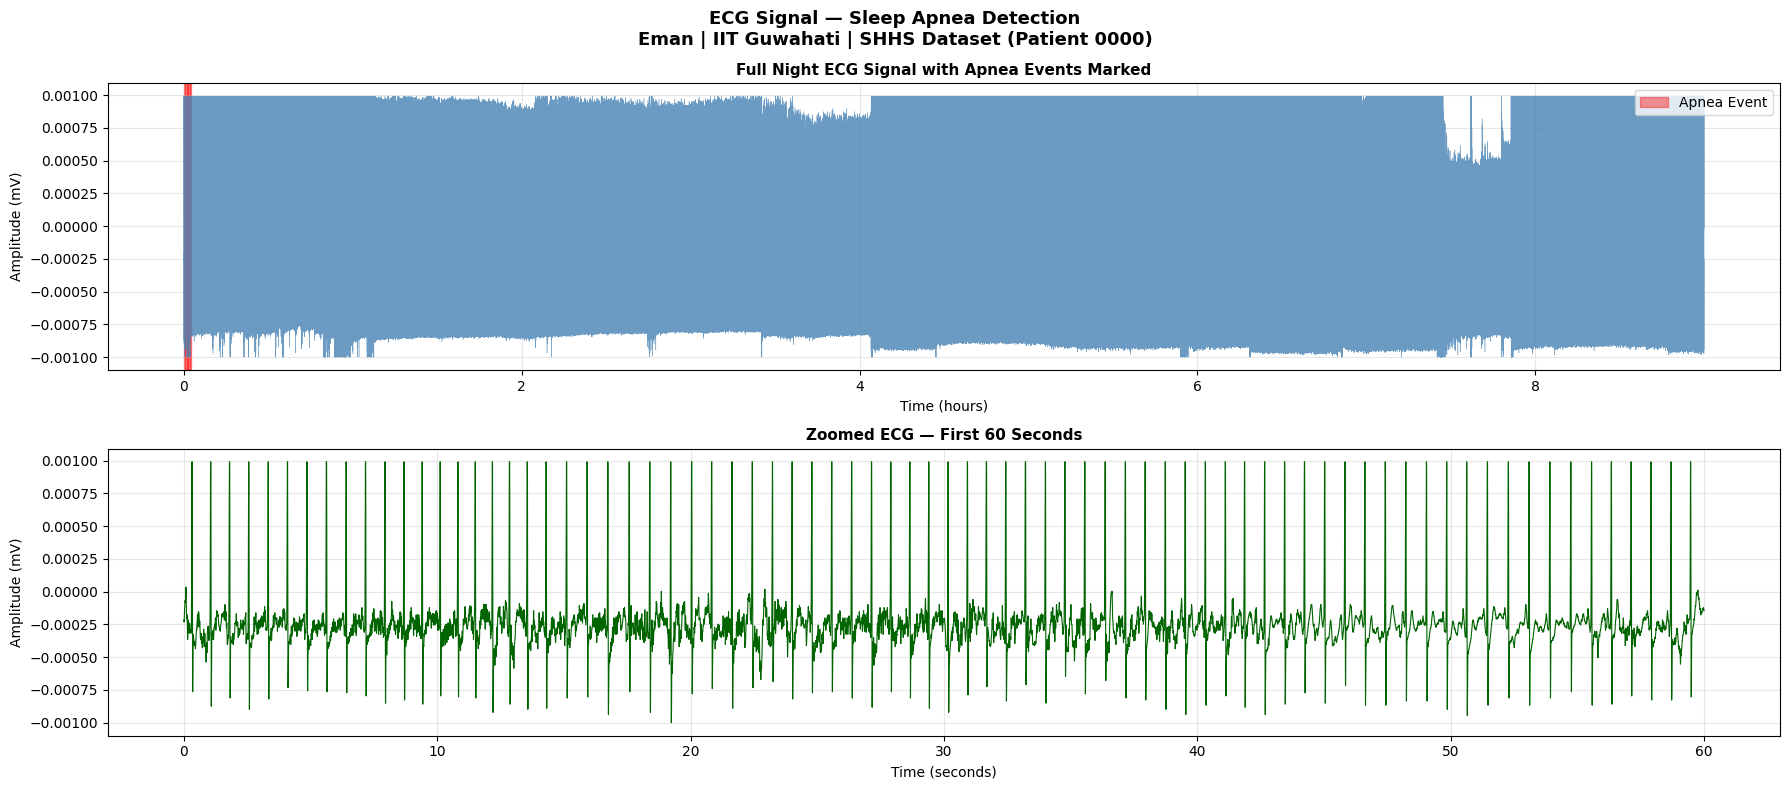

Plot saved


In [17]:
fig, axes = plt.subplots(2, 1, figsize=(18, 8))
fig.suptitle("ECG Signal — Sleep Apnea Detection\nEman | IIT Guwahati | SHHS Dataset (Patient 0000)",
             fontsize=13, fontweight='bold')

# --- Plot 1: Full night ECG with apnea markers ---
ax1 = axes[0]
time_hours = times / 3600
ax1.plot(time_hours, ecg_data, color='steelblue', linewidth=0.3, alpha=0.8)
ax1.set_title("Full Night ECG Signal with Apnea Events Marked", fontsize=11, fontweight='bold')
ax1.set_xlabel("Time (hours)")
ax1.set_ylabel("Amplitude (mV)")
ax1.grid(True, alpha=0.3)

first_label = True
for i, label in enumerate(window_labels):
    if label == 1:
        start = (i * 30) / 3600
        end = ((i + 1) * 30) / 3600
        ax1.axvspan(start, end, color='red', alpha=0.4,
                    label='Apnea Event' if first_label else "")
        first_label = False
ax1.legend(loc='upper right')

# --- Plot 2: Zoomed ECG first 60 seconds ---
ax2 = axes[1]
zoom_samples = int(60 * sfreq)
ax2.plot(times[:zoom_samples], ecg_data[:zoom_samples],
         color='darkgreen', linewidth=0.8)
ax2.set_title("Zoomed ECG — First 60 Seconds", fontsize=11, fontweight='bold')
ax2.set_xlabel("Time (seconds)")
ax2.set_ylabel("Amplitude (mV)")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(r"C:\Users\EmaSk\Desktop\sleep-apnea-detection\eman\ecg_exploration_plot.png", dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved")